In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, Fabelo2DCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data import HSIPixelDataset, HSIPatchDataset
from brainvision.data.io import load_processed_patients
from brainvision.validation import (build_splits_vp1, build_splits_vp2,
                                     build_splits_vp3, build_splits_fabelo,
                                     build_splits_lopo, verify_no_leakage)
from brainvision.utils import build_run_name
from brainvision.metrics import (compute_metrics, aggregate_fold_metrics,
                                  print_metrics, print_aggregate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [2]:
MODEL         = "2D-CNN-Fabelo"      # "1D-NN" | "1D-NN-Fabelo" | "1D-CNN"
                               # "2D-CNN" | "2D-CNN-Fabelo" | "3D-CNN"
                               # "HybridSN" | "SpectralFormer"
LOSS_FN       = "CE"          # "CE" | "FL" | "DL" | "UFL"
STRATEGY      = "vp_fabelo"   # "vp1" | "vp2" | "vp3" | "lopo" | "vp_fabelo"
REDUCE_PIXELS = True          # must match what was used during training
N_FOLDS       = 5             # only relevant for vp3, lopo, vp_fabelo

In [3]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: Fabelo2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band    = SF_NEAR_BAND,
                                              dim          = SF_DIM,
                                              depth        = SF_DEPTH,
                                              heads        = SF_HEADS,
                                              dim_head     = SF_DIM_HEAD,
                                              mlp_dim      = SF_MLP_DIM,
                                              dropout      = SF_DROPOUT,
                                              emb_dropout  = SF_EMB_DROPOUT,
                                              mode         = SF_MODE),
}

In [4]:
def load_all_campaigns() -> dict:
    print("Loading all campaigns...")
    campaigns = {c: load_processed_patients(PROCESSED_DIRS[c]) for c in [1, 2, 3]}
    total = sum(len(v) for v in campaigns.values())
    print(f"Loaded {total} patients across {len(campaigns)} campaigns")
    return campaigns


campaigns = load_all_campaigns()

Loading all campaigns...
  Loaded  27 patients from ../processed/first_campaign
  Loaded  24 patients from ../processed/second_campaign
  Loaded  10 patients from ../processed/third_campaign
Loaded 61 patients across 3 campaigns


In [5]:
def build_all_splits(strategy: str) -> list[dict]:
    """Build splits for the given strategy. Always recomputed fresh."""
    print(f"Building {strategy} splits...")

    if strategy == 'vp1':
        s = build_splits_vp1(campaigns)
        verify_no_leakage(s)
        return [{'fold': None, **s}]

    elif strategy == 'vp2':
        s = build_splits_vp2(campaigns)
        verify_no_leakage(s)
        return [{'fold': None, **s}]

    elif strategy == 'vp3':
        splits = build_splits_vp3(campaigns, n_folds=N_FOLDS)
        for fold in splits: verify_no_leakage(fold)
        return splits

    elif strategy == 'lopo':
        splits = build_splits_lopo(campaigns)
        for fold in splits: verify_no_leakage(fold)
        return splits

    elif strategy == 'vp_fabelo':
        splits = build_splits_fabelo(campaigns, n_folds=N_FOLDS)
        for fold in splits: verify_no_leakage(fold)
        return splits

    else:
        raise ValueError(
            f"Unknown STRATEGY '{strategy}'. "
            f"Choose 'vp1', 'vp2', 'vp3', 'lopo', or 'vp_fabelo'."
        )


all_splits = build_all_splits(STRATEGY)

Building vp_fabelo splits...
Total patients : 34
Per fold       : 20 train / 7 val / 7 test patients
Folds          : 5

  Fold 1: 40 train images / 11 val images / 10 test images  | test patients: ['005', '010', '014', '035', '041', '055', '058']
  Fold 2: 28 train images / 16 val images / 17 test images  | test patients: ['007', '016', '018', '021', '036', '039', '055']
  Fold 3: 35 train images / 14 val images / 12 test images  | test patients: ['004', '014', '016', '018', '019', '050', '057']
  Fold 4: 37 train images / 11 val images / 13 test images  | test patients: ['007', '015', '016', '017', '035', '050', '056']
  Fold 5: 40 train images / 10 val images / 11 test images  | test patients: ['007', '010', '014', '036', '043', '051', '055']
✅ No patient-level leakage detected
✅ No patient-level leakage detected
✅ No patient-level leakage detected
✅ No patient-level leakage detected
✅ No patient-level leakage detected


In [6]:
def get_run_name(split: dict) -> str:
    """Reconstruct run name from split dict using build_run_name."""
    return build_run_name(
        model         = MODEL,
        loss_fn       = LOSS_FN,
        strategy      = STRATEGY,
        fold          = split['fold'],
        reduce_pixels = REDUCE_PIXELS,
    )

def get_all_run_names() -> list[str]:
    return [get_run_name(s) for s in all_splits]

print(f"\nExperiment: {MODEL} × {LOSS_FN} × {STRATEGY} "
      f"({'bal' if REDUCE_PIXELS else 'nobal'})")
print(f"\nRun names:")
for name in get_all_run_names():
    exists_h  = (Path(RESULTS_DIR)     / f"{name}_history.npy").exists()
    exists_cp = (Path(CHECKPOINTS_DIR) / f"{name}.pt").exists()
    h_tag  = "✅" if exists_h  else "❌"
    cp_tag = "✅" if exists_cp else "❌"
    print(f"  {name}  history={h_tag}  checkpoint={cp_tag}")


Experiment: 2D-CNN-Fabelo × CE × vp_fabelo (bal)

Run names:
  2dcnnfabelo_ce_bal_fold1_vpfabelo  history=✅  checkpoint=✅
  2dcnnfabelo_ce_bal_fold2_vpfabelo  history=✅  checkpoint=✅
  2dcnnfabelo_ce_bal_fold3_vpfabelo  history=✅  checkpoint=✅
  2dcnnfabelo_ce_bal_fold4_vpfabelo  history=✅  checkpoint=✅
  2dcnnfabelo_ce_bal_fold5_vpfabelo  history=✅  checkpoint=✅


In [7]:
def load_history(run_name: str) -> dict | None:
    path = Path(RESULTS_DIR) / f"{run_name}_history.npy"
    if not path.exists():
        print(f"  ⚠️  History not found: {path}")
        return None
    return np.load(path, allow_pickle=True).item()

In [8]:
def plot_training_curves(history: dict, run_name: str):
    """
    Plot loss, Val F1 (all + no-BG), sensitivity and specificity
    across training epochs. Marks the best epoch.
    """
    epochs  = range(1, len(history['train_loss']) + 1)
    best_ep = history.get('best_epoch', 1)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Training Curves — {run_name}", fontsize=13)

    def _vline(ax):
        ax.axvline(best_ep, color='gray', linestyle='--',
                   alpha=0.6, label=f'Best epoch ({best_ep})')

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], label='Train', color='#378ADD')
    ax.plot(epochs, history['val_loss'],   label='Val',   color='#D85A30')
    _vline(ax)
    ax.set_title("Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    # ── Val F1 (all classes) ──────────────────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(epochs, history['val_f1'], color='#5DCAA5')
    best_f1_all = history.get('best_f1_all', history['val_f1'][best_ep - 1])
    ax.scatter([best_ep], [best_f1_all], color='#5DCAA5', zorder=5, s=60)
    _vline(ax)
    ax.set_title(f"Val Macro F1 — all classes  (best={best_f1_all:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1)

    # ── Val F1 (no BG) ────────────────────────────────────────────────────────
    ax = axes[0, 2]
    if history.get('val_f1_no_bg'):
        ax.plot(epochs, history['val_f1_no_bg'], color='#7F77DD')
        best_f1_no_bg = history.get('best_f1', history['val_f1_no_bg'][best_ep - 1])
        ax.scatter([best_ep], [best_f1_no_bg], color='#7F77DD', zorder=5, s=60)
        _vline(ax)
        ax.set_title(f"Val Macro F1 — no BG  (best={best_f1_no_bg:.4f})")
    else:
        ax.text(0.5, 0.5, 'val_f1_no_bg\nnot recorded',
                ha='center', va='center', transform=ax.transAxes,
                color='gray', fontsize=11)
        ax.set_title("Val Macro F1 — no BG")
        best_f1_no_bg = float('nan')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1)

    # ── Sensitivity ───────────────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(epochs, history['val_sens'], color='#EF9F27')
    best_sens = history.get('best_sens', history['val_sens'][best_ep - 1])
    ax.scatter([best_ep], [best_sens], color='#EF9F27', zorder=5, s=60)
    _vline(ax)
    ax.set_title(f"Val Sensitivity — macro  (best={best_sens:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Sensitivity"); ax.set_ylim(0, 1)

    # ── Specificity ───────────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(epochs, history['val_spec'], color='#639922')
    best_spec = history.get('best_spec', history['val_spec'][best_ep - 1])
    ax.scatter([best_ep], [best_spec], color='#639922', zorder=5, s=60)
    _vline(ax)
    ax.set_title(f"Val Specificity — macro  (best={best_spec:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Specificity"); ax.set_ylim(0, 1)

    # ── Summary text ──────────────────────────────────────────────────────────
    ax = axes[1, 2]
    ax.axis('off')
    balance_str = history.get('balance', REDUCE_PIXELS)
    summary = (
        f"Run      : {run_name}\n\n"
        f"Model    : {MODEL}\n"
        f"Loss     : {LOSS_FN}\n"
        f"Strategy : {STRATEGY}\n"
        f"Balanced : {'Yes' if balance_str else 'No'}\n\n"
        f"Best epoch     : {best_ep}\n"
        f"Val F1 (all)   : {best_f1_all:.4f}\n"
        f"Val F1 (no BG) : {best_f1_no_bg:.4f}\n"
        f"Val Sensitivity: {best_sens:.4f}\n"
        f"Val Specificity: {best_spec:.4f}\n"
        f"Total epochs   : {len(history['train_loss'])}"
    )
    ax.text(0.05, 0.95, summary, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{run_name}_curves.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {RESULTS_DIR}/{run_name}_curves.png")


════════════════════════════════════════════════════════════
  Training Curves — 2D-CNN-Fabelo × CE × vp_fabelo
════════════════════════════════════════════════════════════


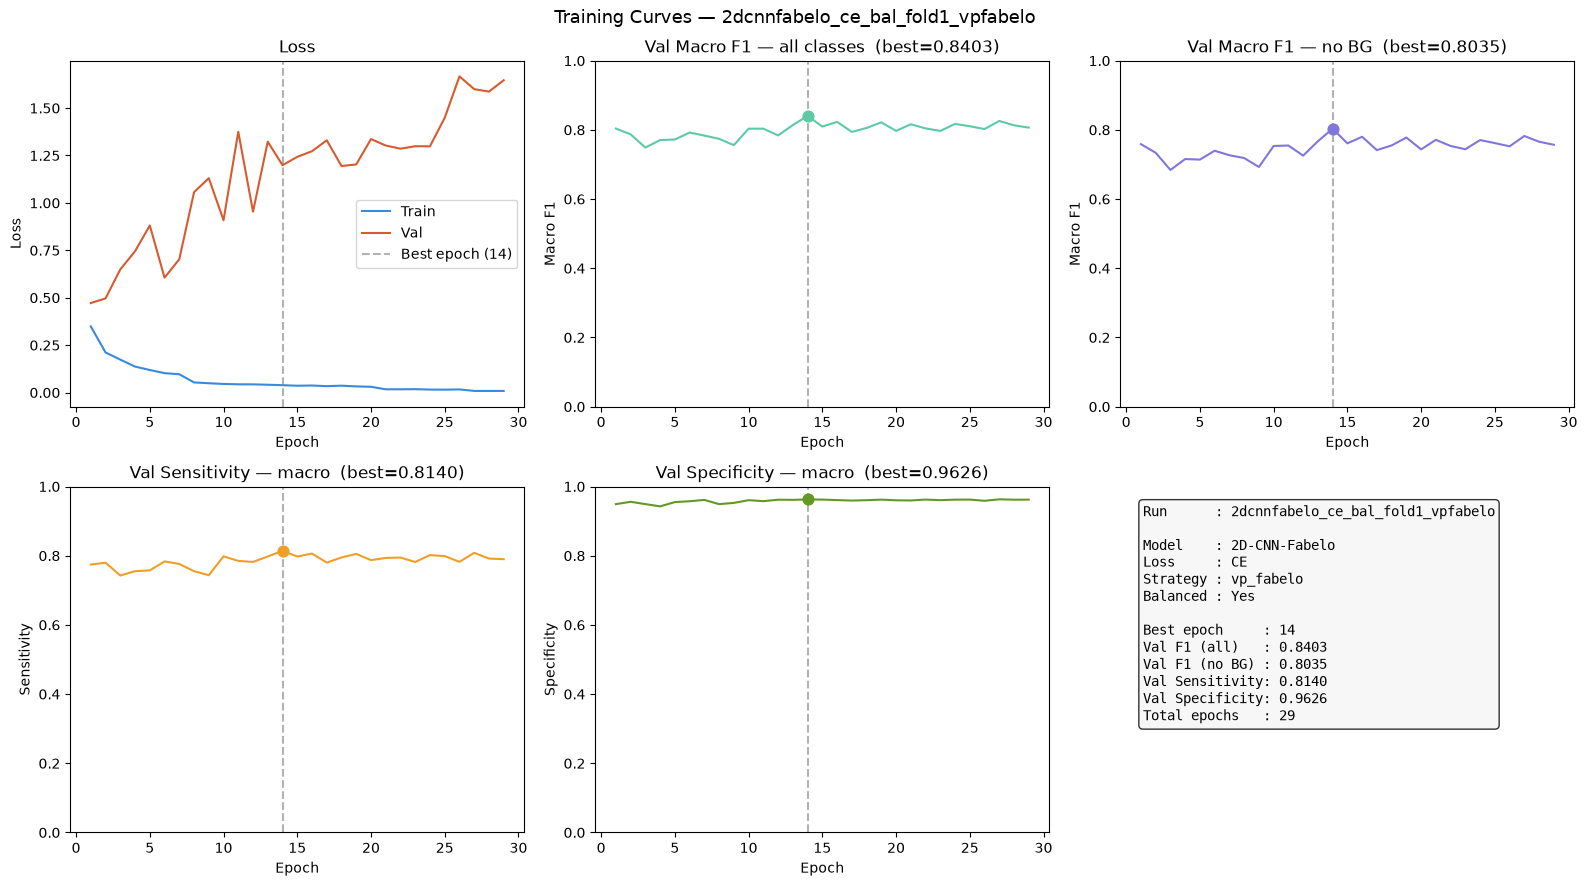

  Saved → ../results/2dcnnfabelo_ce_bal_fold1_vpfabelo_curves.png


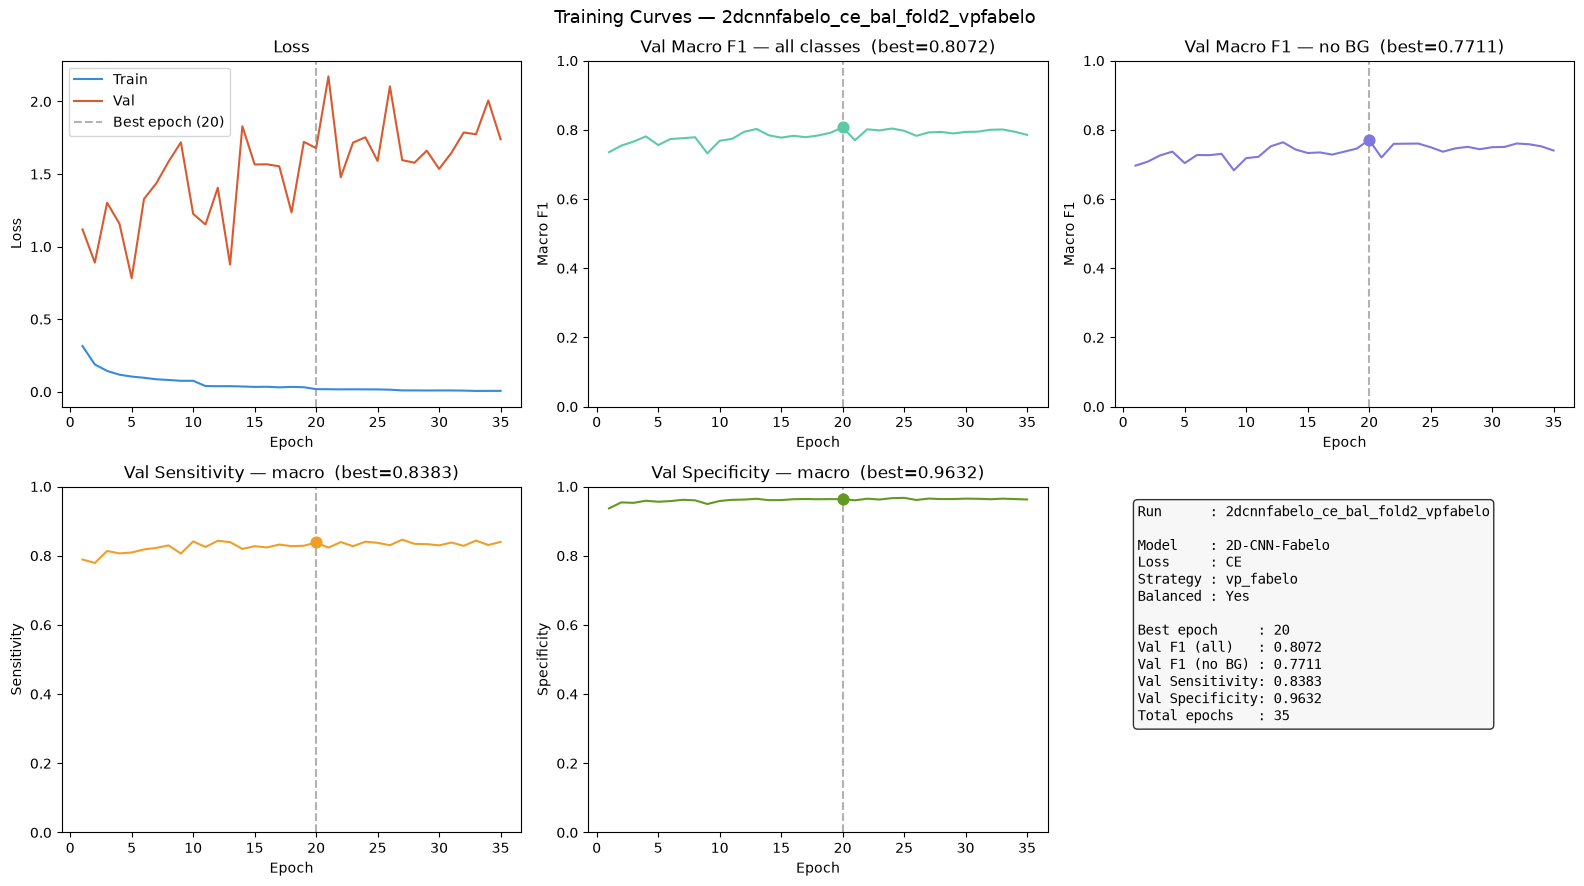

  Saved → ../results/2dcnnfabelo_ce_bal_fold2_vpfabelo_curves.png


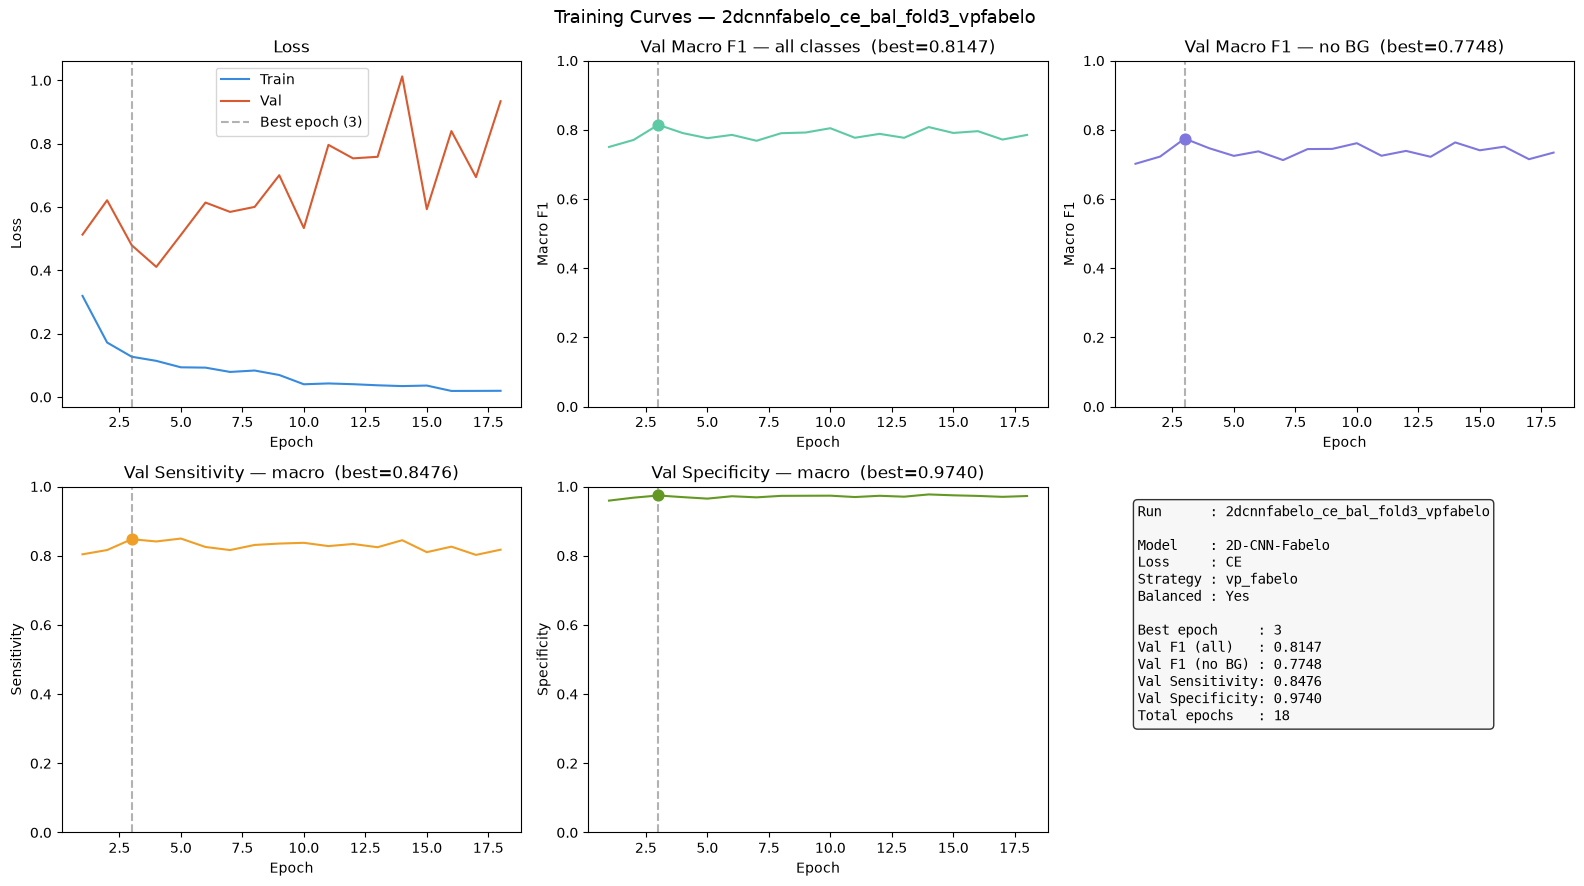

  Saved → ../results/2dcnnfabelo_ce_bal_fold3_vpfabelo_curves.png


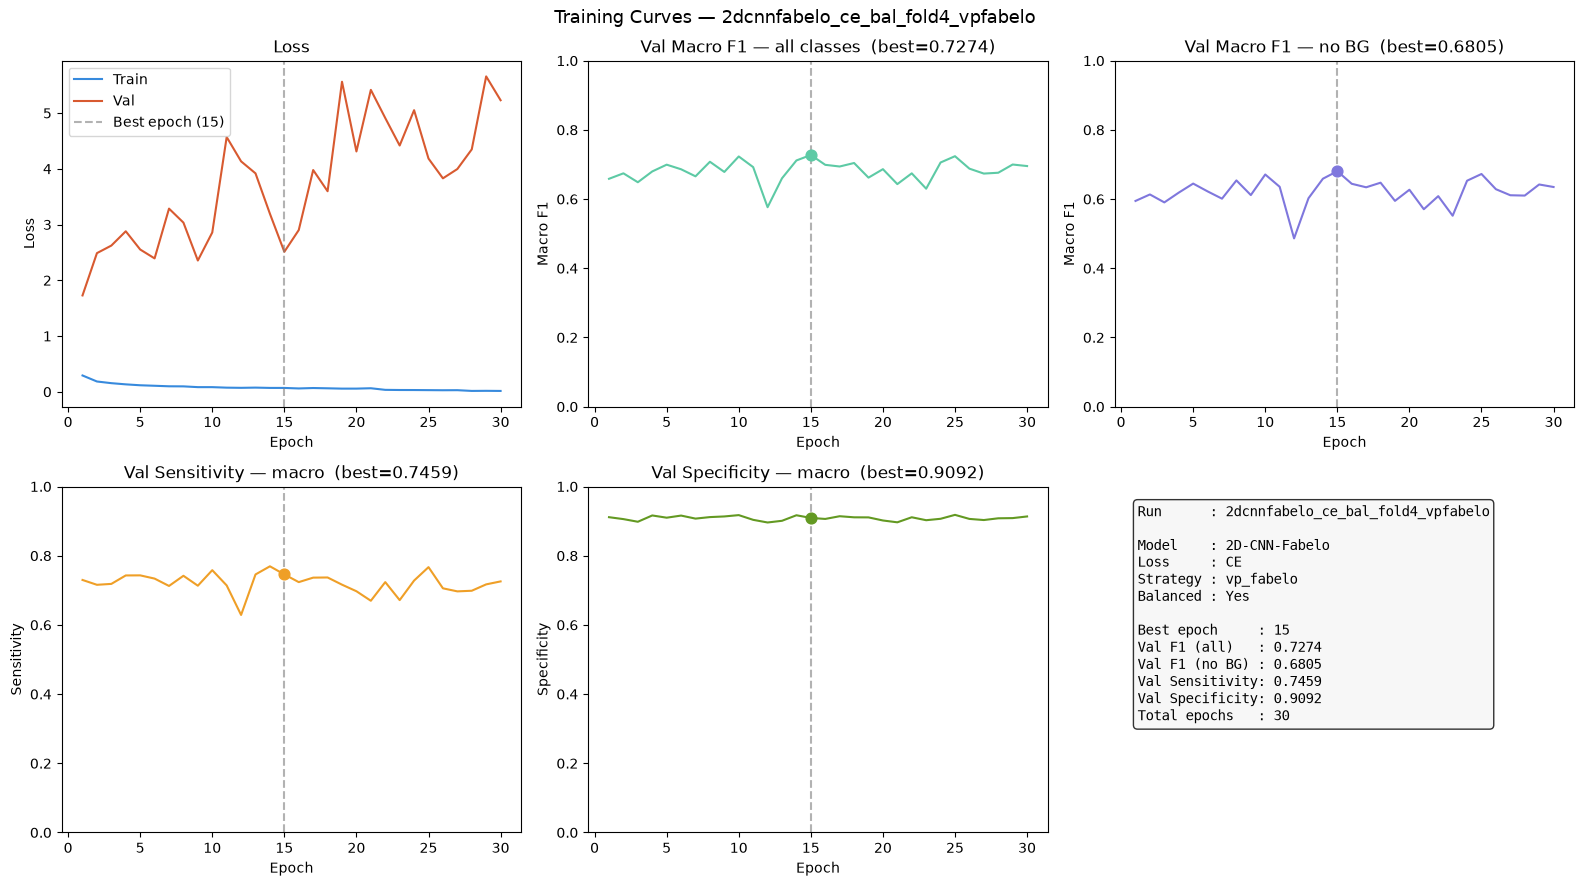

  Saved → ../results/2dcnnfabelo_ce_bal_fold4_vpfabelo_curves.png


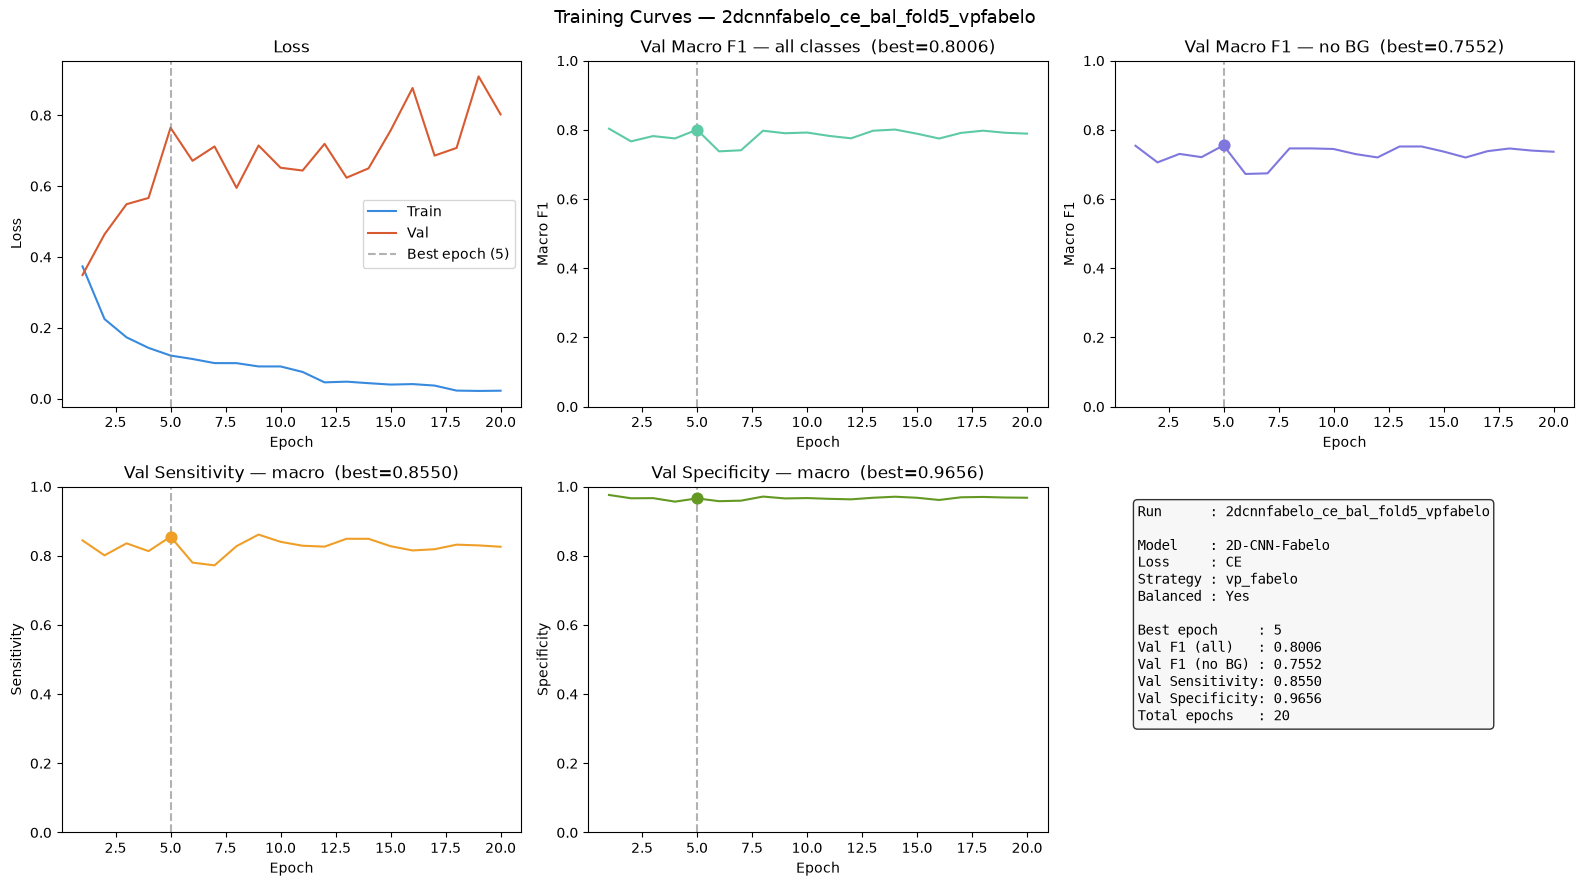

  Saved → ../results/2dcnnfabelo_ce_bal_fold5_vpfabelo_curves.png


In [9]:
print(f"\n{'═'*60}")
print(f"  Training Curves — {MODEL} × {LOSS_FN} × {STRATEGY}")
print(f"{'═'*60}")

for split in all_splits:
    run_name = get_run_name(split)
    history  = load_history(run_name)
    if history:
        plot_training_curves(history, run_name)

In [ ]:
@torch.no_grad()
def predict(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_targets = [], []
    for X, y in loader:
        X      = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
    return np.array(all_preds), np.array(all_targets)


def plot_confusion_matrix(metrics: dict):
    cm   = metrics['confusion_matrix']
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp    = ConfusionMatrixDisplay(
        confusion_matrix = cm_n,
        display_labels   = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f"Confusion Matrix — {metrics['run_name']}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{metrics['run_name']}_cm.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def build_test_loader(split: dict) -> DataLoader:
    """Build test DataLoader — always unbalanced, never augmented."""
    test_patients = split['test']
    if MODEL in PATCH_MODELS:
        test_dataset = HSIPatchDataset(
            test_patients,
            patch_size = PATCH_SIZE,
            balance    = False,
            augment    = False,
        )
    else:
        test_dataset = HSIPixelDataset(test_patients)
    return DataLoader(test_dataset, batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
def evaluate_fold(split: dict) -> dict | None:
    run_name        = get_run_name(split)
    checkpoint_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

    if not checkpoint_path.exists():
        print(f"  ⚠️  Checkpoint not found: {checkpoint_path}")
        return None

    print(f"\n{'─'*60}")
    print(f"  Evaluating : {run_name}")
    if 'val_patient' in split:
        print(f"  Val patient: {split['val_patient']}")
    print(f"  Test images: {len(split['test'])}")
    print(f"{'─'*60}")

    test_loader = build_test_loader(split)

    model = MODEL_REGISTRY[MODEL]().to(device)
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )

    preds, targets = predict(model, test_loader)
    metrics        = compute_metrics(targets, preds, run_name)

    print_metrics(metrics)
    plot_confusion_matrix(metrics)

    print(classification_report(
        targets, preds,
        target_names = [CLASS_NAMES[i+1] for i in range(N_CLASSES)],
        digits=4, zero_division=0
    ))

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    print(f"  Saved → {RESULTS_DIR}/{run_name}_test_metrics.npy")

    return metrics


────────────────────────────────────────────────────────────
  Evaluating : 2dcnnfabelo_ce_bal_fold1_vpfabelo
  Test images: 10
────────────────────────────────────────────────────────────
  Lazy dataset: 167,484 patches (extracted on-the-fly)


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



════════════════════════════════════════════════════════════════════
  TEST RESULTS — 2dcnnfabelo_ce_bal_fold1_vpfabelo
════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)    : 0.9187
  Macro F1 (all classes)   : 0.7960
  Macro F1 (no BG)         : 0.7420  ← Fabelo benchmark metric

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.9201       0.9522   0.8933
  Tumour Tissue (TT)              0.4248       0.9893   0.4623  ← clinical priority
  Blood Vessel (BV)               0.8436       0.9862   0.8702
  Background (BG)                 0.9552       0.9431   0.9580
  ────────────────────────────────────────────────────────────
  Mean                            0.7859       0.9677   0.7960


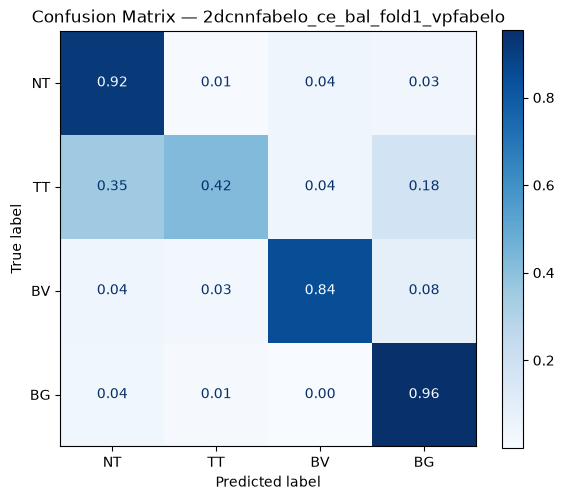

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8681    0.9201    0.8933     42662
Tumour Tissue (TT)     0.5072    0.4248    0.4623      4240
 Blood Vessel (BV)     0.8986    0.8436    0.8702     21247
   Background (BG)     0.9607    0.9552    0.9580     99335

          accuracy                         0.9187    167484
         macro avg     0.8086    0.7859    0.7960    167484
      weighted avg     0.9178    0.9187    0.9178    167484

  Saved → ../results/2dcnnfabelo_ce_bal_fold1_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 2dcnnfabelo_ce_bal_fold2_vpfabelo
  Test images: 17
────────────────────────────────────────────────────────────
  Lazy dataset: 199,089 patches (extracted on-the-fly)


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



════════════════════════════════════════════════════════════════════
  TEST RESULTS — 2dcnnfabelo_ce_bal_fold2_vpfabelo
════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)    : 0.8861
  Macro F1 (all classes)   : 0.7297
  Macro F1 (no BG)         : 0.6602  ← Fabelo benchmark metric

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8378       0.9922   0.9047
  Tumour Tissue (TT)              0.5170       0.9439   0.2463  ← clinical priority
  Blood Vessel (BV)               0.9535       0.9652   0.8296
  Background (BG)                 0.9205       0.9520   0.9383
  ────────────────────────────────────────────────────────────
  Mean                            0.8072       0.9633   0.7297


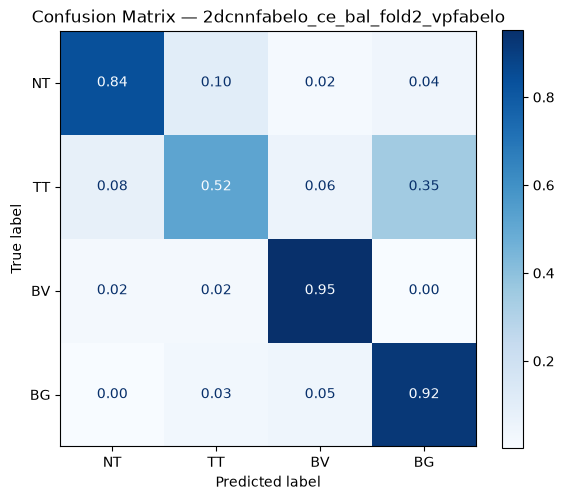

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9832    0.8378    0.9047     70175
Tumour Tissue (TT)     0.1617    0.5170    0.2463      4079
 Blood Vessel (BV)     0.7342    0.9535    0.8296     18232
   Background (BG)     0.9567    0.9205    0.9383    106603

          accuracy                         0.8861    199089
         macro avg     0.7089    0.8072    0.7297    199089
      weighted avg     0.9294    0.8861    0.9023    199089

  Saved → ../results/2dcnnfabelo_ce_bal_fold2_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 2dcnnfabelo_ce_bal_fold3_vpfabelo
  Test images: 12
────────────────────────────────────────────────────────────
  Lazy dataset: 124,889 patches (extracted on-the-fly)


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



════════════════════════════════════════════════════════════════════
  TEST RESULTS — 2dcnnfabelo_ce_bal_fold3_vpfabelo
════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)    : 0.8801
  Macro F1 (all classes)   : 0.6906
  Macro F1 (no BG)         : 0.6114  ← Fabelo benchmark metric

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8788       0.9813   0.9177
  Tumour Tissue (TT)              0.4667       0.9406   0.1732  ← clinical priority
  Blood Vessel (BV)               0.9356       0.9618   0.7433
  Background (BG)                 0.8856       0.9683   0.9282
  ────────────────────────────────────────────────────────────
  Mean                            0.7917       0.9630   0.6906


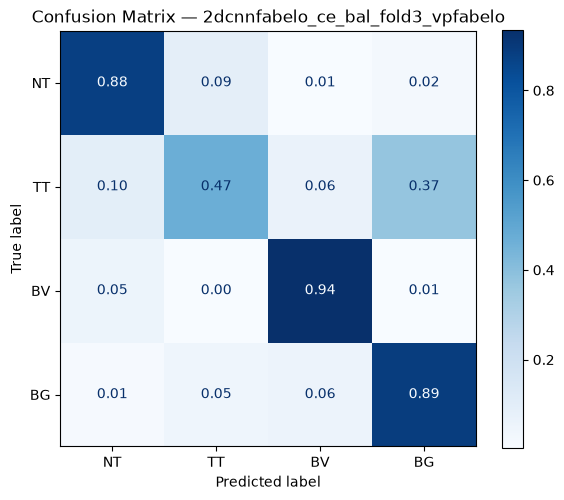

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9603    0.8788    0.9177     42401
Tumour Tissue (TT)     0.1063    0.4667    0.1732      1862
 Blood Vessel (BV)     0.6166    0.9356    0.7433      7704
   Background (BG)     0.9751    0.8856    0.9282     72922

          accuracy                         0.8801    124889
         macro avg     0.6646    0.7917    0.6906    124889
      weighted avg     0.9350    0.8801    0.9020    124889

  Saved → ../results/2dcnnfabelo_ce_bal_fold3_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 2dcnnfabelo_ce_bal_fold4_vpfabelo
  Test images: 13
────────────────────────────────────────────────────────────
  Lazy dataset: 130,594 patches (extracted on-the-fly)


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



════════════════════════════════════════════════════════════════════
  TEST RESULTS — 2dcnnfabelo_ce_bal_fold4_vpfabelo
════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)    : 0.8326
  Macro F1 (all classes)   : 0.7401
  Macro F1 (no BG)         : 0.6845  ← Fabelo benchmark metric

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.7729       0.9535   0.8088
  Tumour Tissue (TT)              0.4618       0.9232   0.3681  ← clinical priority
  Blood Vessel (BV)               0.8782       0.9786   0.8767
  Background (BG)                 0.8958       0.9084   0.9068
  ────────────────────────────────────────────────────────────
  Mean                            0.7522       0.9409   0.7401


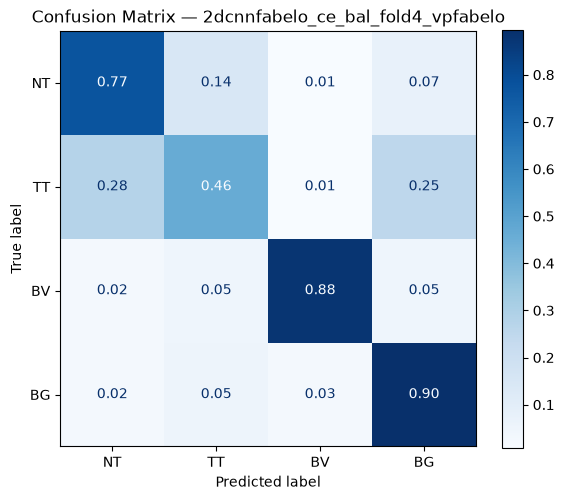

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8482    0.7729    0.8088     32849
Tumour Tissue (TT)     0.3061    0.4618    0.3681      8928
 Blood Vessel (BV)     0.8752    0.8782    0.8767     19094
   Background (BG)     0.9181    0.8958    0.9068     69723

          accuracy                         0.8326    130594
         macro avg     0.7369    0.7522    0.7401    130594
      weighted avg     0.8524    0.8326    0.8409    130594

  Saved → ../results/2dcnnfabelo_ce_bal_fold4_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : 2dcnnfabelo_ce_bal_fold5_vpfabelo
  Test images: 11
────────────────────────────────────────────────────────────
  Lazy dataset: 198,062 patches (extracted on-the-fly)


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



════════════════════════════════════════════════════════════════════
  TEST RESULTS — 2dcnnfabelo_ce_bal_fold5_vpfabelo
════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)    : 0.9376
  Macro F1 (all classes)   : 0.8455
  Macro F1 (no BG)         : 0.8093  ← Fabelo benchmark metric

  Class                      Sensitivity  Specificity     Dice
  ────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.9094       0.9907   0.9477
  Tumour Tissue (TT)              0.9149       0.9712   0.5263  ← clinical priority
  Blood Vessel (BV)               0.9204       0.9987   0.9538
  Background (BG)                 0.9812       0.9550   0.9541
  ────────────────────────────────────────────────────────────
  Mean                            0.9315       0.9789   0.8455


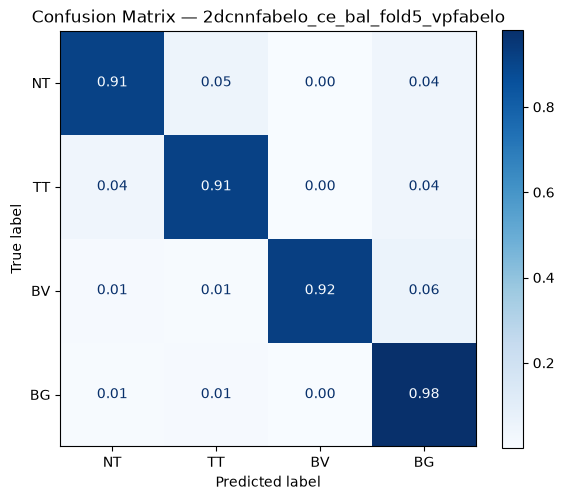

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9894    0.9094    0.9477     96918
Tumour Tissue (TT)     0.3694    0.9149    0.5263      3586
 Blood Vessel (BV)     0.9898    0.9204    0.9538     23660
   Background (BG)     0.9284    0.9812    0.9541     73898

          accuracy                         0.9376    198062
         macro avg     0.8192    0.9315    0.8455    198062
      weighted avg     0.9555    0.9376    0.9432    198062

  Saved → ../results/2dcnnfabelo_ce_bal_fold5_vpfabelo_test_metrics.npy


In [12]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

all_metrics = []
for split in all_splits:
    metrics = evaluate_fold(split)
    if metrics:
        all_metrics.append(metrics)

In [13]:
def aggregate_folds(all_metrics: list[dict]) -> dict:
    """
    Compute median ± std across folds for all key metrics.
    Matches Fabelo et al. reporting convention.
    """
    if not all_metrics:
        print("No metrics to aggregate.")
        return {}

    f1_all   = [m['macro_f1']       for m in all_metrics]
    f1_no_bg = [m['macro_f1_no_bg'] for m in all_metrics]
    oas      = [m['oa']             for m in all_metrics]
    tt_sens  = [m['sensitivity'][1] for m in all_metrics]   # TT = index 1
    nt_sens  = [m['sensitivity'][0] for m in all_metrics]
    bv_sens  = [m['sensitivity'][2] for m in all_metrics]
    bg_sens  = [m['sensitivity'][3] for m in all_metrics]

    result = {
        'n_folds'            : len(all_metrics),
        'macro_f1_median'    : np.median(f1_all),
        'macro_f1_std'       : np.std(f1_all),
        'macro_f1_no_bg_median': np.median(f1_no_bg),
        'macro_f1_no_bg_std' : np.std(f1_no_bg),
        'oa_median'          : np.median(oas),
        'oa_std'             : np.std(oas),
        'tt_sens_median'     : np.median(tt_sens),
        'tt_sens_std'        : np.std(tt_sens),
        'nt_sens_median'     : np.median(nt_sens),
        'bv_sens_median'     : np.median(bv_sens),
        'bg_sens_median'     : np.median(bg_sens),
        'per_fold_f1_no_bg'  : f1_no_bg,
    }

    print(f"\n{'═'*60}")
    print(f"  AGGREGATE — {MODEL} × {LOSS_FN} × {STRATEGY}")
    print(f"  ({result['n_folds']} folds)")
    print(f"{'═'*60}")
    print(f"  Macro F1 (all)   : {result['macro_f1_median']*100:.1f} "
          f"± {result['macro_f1_std']*100:.1f}%")
    print(f"  Macro F1 (no BG) : {result['macro_f1_no_bg_median']*100:.1f} "
          f"± {result['macro_f1_no_bg_std']*100:.1f}%  ← compare vs Fabelo 70.2 ± 7.9%")
    print(f"  OA               : {result['oa_median']*100:.1f} "
          f"± {result['oa_std']*100:.1f}%")
    print(f"\n  Per-class sensitivity (median):")
    print(f"    NT : {result['nt_sens_median']*100:.1f}%")
    print(f"    TT : {result['tt_sens_median']*100:.1f}%  ← clinical priority")
    print(f"    BV : {result['bv_sens_median']*100:.1f}%")
    print(f"    BG : {result['bg_sens_median']*100:.1f}%")
    print(f"\n  Per-fold F1 (no BG): "
          f"{[f'{v*100:.1f}%' for v in f1_no_bg]}")

    # Save aggregate
    agg_name = f"{MODEL.lower().replace('-','')}_{LOSS_FN.lower()}_{STRATEGY}_aggregate"
    np.save(f"{RESULTS_DIR}/{agg_name}.npy", result)
    print(f"\n  Saved → {RESULTS_DIR}/{agg_name}.npy")

    return result


aggregate = aggregate_folds(all_metrics)


════════════════════════════════════════════════════════════
  AGGREGATE — 2D-CNN-Fabelo × CE × vp_fabelo
  (5 folds)
════════════════════════════════════════════════════════════
  Macro F1 (all)   : 74.0 ± 5.4%
  Macro F1 (no BG) : 68.5 ± 6.8%  ← compare vs Fabelo 70.2 ± 7.9%
  OA               : 88.6 ± 3.6%

  Per-class sensitivity (median):
    NT : 87.9%
    TT : 46.7%  ← clinical priority
    BV : 92.0%
    BG : 92.0%

  Per-fold F1 (no BG): ['74.2%', '66.0%', '61.1%', '68.5%', '80.9%']

  Saved → ../results/2dcnnfabelo_ce_vp_fabelo_aggregate.npy
